# Feature Engineering and Machine Learning Model Building
Objective

Prepare the cleaned dataset for machine learning by creating useful features, encoding categorical variables, selecting predictors, and training regression models to predict Air Quality Index (AQI).

In [1]:
import pandas as pd
import numpy as np

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [3]:
air_df = pd.read_csv("air_quality_cleaned.csv")
air_df

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-29,83.13,96.18,6.93,28.71,33.72,16.31,6.93,49.52,59.76,0.02,0.000,209.0,Poor
1,Ahmedabad,2015-01-30,79.84,96.18,13.85,28.68,41.08,16.31,13.85,48.49,97.07,0.04,0.000,328.0,Very Poor
2,Ahmedabad,2015-01-31,94.52,96.18,24.39,32.66,52.61,16.31,24.39,67.39,111.33,0.24,0.010,514.0,Severe
3,Ahmedabad,2015-02-01,135.99,96.18,43.48,42.08,84.57,16.31,43.48,75.23,102.70,0.40,0.040,782.0,Severe
4,Ahmedabad,2015-02-02,178.33,96.18,54.56,35.31,72.80,16.31,54.56,55.04,107.38,0.46,0.060,914.0,Severe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24845,Visakhapatnam,2020-06-27,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.070,41.0,Good
24846,Visakhapatnam,2020-06-28,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.210,70.0,Satisfactory
24847,Visakhapatnam,2020-06-29,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.010,68.0,Satisfactory
24848,Visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.000,54.0,Satisfactory


In [4]:
air_df["Date"] = pd.to_datetime(air_df["Date"])
air_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24850 entries, 0 to 24849
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   City        24850 non-null  str           
 1   Date        24850 non-null  datetime64[us]
 2   PM2.5       24850 non-null  float64       
 3   PM10        24850 non-null  float64       
 4   NO          24850 non-null  float64       
 5   NO2         24850 non-null  float64       
 6   NOx         24850 non-null  float64       
 7   NH3         24850 non-null  float64       
 8   CO          24850 non-null  float64       
 9   SO2         24850 non-null  float64       
 10  O3          24850 non-null  float64       
 11  Benzene     24850 non-null  float64       
 12  Toluene     24850 non-null  float64       
 13  AQI         24850 non-null  float64       
 14  AQI_Bucket  24850 non-null  str           
dtypes: datetime64[us](1), float64(12), str(2)
memory usage: 3.2 MB


In [5]:
air_df["Year"] = air_df["Date"].dt.year
air_df["Month"] = air_df["Date"].dt.month
air_df["Day"] = air_df["Date"].dt.day
air_df["DayOfWeek"] = air_df["Date"].dt.day_name()

# Check new columns
air_df[["Date","Year","Month","Day","DayOfWeek"]].head()

,Date,Year,Month,Day,DayOfWeek
0,2015-01-29,2015,1,29,Thursday
1,2015-01-30,2015,1,30,Friday
2,2015-01-31,2015,1,31,Saturday
3,2015-02-01,2015,2,1,Sunday
4,2015-02-02,2015,2,2,Monday


In [6]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8, 9]:
        return "Monsoon"
    else:
        return "Post-Monsoon"

air_df["Season"] = air_df["Month"].apply(get_season)

# Check values
air_df[["Date","Month","Season"]].head()

,Date,Month,Season
0,2015-01-29,1,Winter
1,2015-01-30,1,Winter
2,2015-01-31,1,Winter
3,2015-02-01,2,Winter
4,2015-02-02,2,Winter


In [7]:
air_df["Season"].value_counts()

Season
Monsoon         7713
Summer          7069
Winter          6243
Post-Monsoon    3825
Name: count, dtype: int64

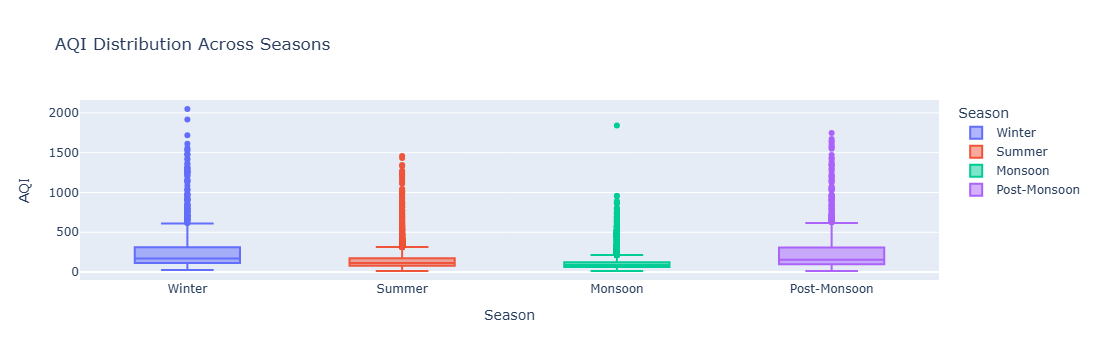

In [8]:
import plotly.express as px

fig = px.box(
    air_df,
    x="Season",
    y="AQI",
    color="Season",
    title="AQI Distribution Across Seasons"
)

fig.show()

In [9]:
from sklearn.preprocessing import LabelEncoder
city_encoder = LabelEncoder()
air_df["City_Encoded"] = city_encoder.fit_transform(air_df["City"])
air_df[["City","City_Encoded"]].head()

,City,City_Encoded
0,Ahmedabad,0
1,Ahmedabad,0
2,Ahmedabad,0
3,Ahmedabad,0
4,Ahmedabad,0


In [10]:
season_encoder = LabelEncoder()
day_encoder = LabelEncoder()

air_df["Season_Encoded"] = season_encoder.fit_transform(air_df["Season"])
air_df["DayOfWeek_Encoded"] = day_encoder.fit_transform(air_df["DayOfWeek"])

air_df[["Season","Season_Encoded","DayOfWeek","DayOfWeek_Encoded"]].head()

,Season,Season_Encoded,DayOfWeek,DayOfWeek_Encoded
0,Winter,3,Thursday,4
1,Winter,3,Friday,0
2,Winter,3,Saturday,2
3,Winter,3,Sunday,3
4,Winter,3,Monday,1


In [11]:
# Create model dataframe

model_df = air_df.drop(
    columns=[
        "Date",
        "City",
        "AQI_Bucket",
        "Season",
        "DayOfWeek"
    ]
)

model_df.head()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,Year,Month,Day,City_Encoded,Season_Encoded,DayOfWeek_Encoded
0,83.13,96.18,6.93,28.71,33.72,16.31,6.93,49.52,59.76,0.02,0.00,209.0,2015,1,29,0,3,4
1,79.84,96.18,13.85,28.68,41.08,16.31,13.85,48.49,97.07,0.04,0.00,328.0,2015,1,30,0,3,0
2,94.52,96.18,24.39,32.66,52.61,16.31,24.39,67.39,111.33,0.24,0.01,514.0,2015,1,31,0,3,2
3,135.99,96.18,43.48,42.08,84.57,16.31,43.48,75.23,102.70,0.40,0.04,782.0,2015,2,1,0,3,3
4,178.33,96.18,54.56,35.31,72.80,16.31,54.56,55.04,107.38,0.46,0.06,914.0,2015,2,2,0,3,1


In [12]:
model_df.columns

Index(['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3',
       'Benzene', 'Toluene', 'AQI', 'Year', 'Month', 'Day', 'City_Encoded',
       'Season_Encoded', 'DayOfWeek_Encoded'],
      dtype='str')

In [13]:
model_df.to_csv("air_quality_feature_engineered.csv", index=False)

# Feature Scaling and Train-Test Split

Before training machine learning models, the dataset is prepared by separating input features and target values. Numerical features are standardized so that all variables are on a similar scale. Finally, the dataset is split into training and testing sets to evaluate the model on unseen data.

In [14]:
# Separate input features and target

X = model_df.drop("AQI", axis=1)
y = model_df["AQI"]

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (24850, 17)
Target Shape   : (24850,)


In [15]:
# Scale numerical features

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Feature scaling completed.")
print(X_scaled[:5])

Feature scaling completed.
[[ 2.59518271e-01 -2.08621183e-01 -4.74820807e-01 -6.55144506e-03
   7.00100106e-02 -2.47358257e-01  6.57273445e-01  2.04735412e+00
   1.16782388e+00 -2.10492903e-01 -4.40855961e-01 -2.08046974e+00
  -1.53661119e+00  1.49823369e+00 -1.70225249e+00  1.30031441e+00
   4.95356127e-01]
 [ 2.06694170e-01 -2.08621183e-01 -1.64031641e-01 -7.77858794e-03
   3.18415463e-01 -2.47358257e-01  1.64388004e+00  1.98758545e+00
   2.91305311e+00 -2.09147972e-01 -4.40855961e-01 -2.08046974e+00
  -1.53661119e+00  1.61155590e+00 -1.70225249e+00  1.30031441e+00
  -1.50401038e+00]
 [ 4.42395628e-01 -2.08621183e-01  3.09337983e-01  1.55022367e-01
   7.07561505e-01 -2.47358257e-01  3.14660165e+00  3.08431151e+00
   3.58008525e+00 -1.95698666e-01 -4.40313742e-01 -2.08046974e+00
  -1.53661119e+00  1.72487812e+00 -1.70225249e+00  1.30031441e+00
  -5.04327128e-01]
 [ 1.10823619e+00 -2.08621183e-01  1.16670289e+00  5.40345232e-01
   1.78623518e+00 -2.47358257e-01  5.86832418e+00  3.53924

In [16]:
# Split dataset into training and testing data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (19880, 17)
Testing Features  : (4970, 17)
Training Labels   : (19880,)
Testing Labels    : (4970,)
